In [6]:
from pymongo import MongoClient
import pandas as pd
from sklearn.linear_model import LinearRegression

# --------------------------
# MongoDB 연결
# --------------------------

client = MongoClient("mongodb://localhost:27017/")

db = client["ai_test_"]

train_collection = db["train_data"]
predict_collection = db["prediction_result"]


In [7]:
# --------------------------
# 샘플 데이터 저장
# --------------------------

sample_data = [
    {"temperature":70,"pressure":100,"vibration":0.10,"quality_score":80},
    {"temperature":75,"pressure":110,"vibration":0.15,"quality_score":85},
    {"temperature":80,"pressure":120,"vibration":0.20,"quality_score":88},
    {"temperature":85,"pressure":130,"vibration":0.25,"quality_score":92},
    {"temperature":90,"pressure":140,"vibration":0.30,"quality_score":95}
]

train_collection.delete_many({})
train_collection.insert_many(sample_data)

InsertManyResult([ObjectId('6a1cfd924e1ac2cb3a603131'), ObjectId('6a1cfd924e1ac2cb3a603132'), ObjectId('6a1cfd924e1ac2cb3a603133'), ObjectId('6a1cfd924e1ac2cb3a603134'), ObjectId('6a1cfd924e1ac2cb3a603135')], acknowledged=True)

In [8]:
# --------------------------
# MongoDB 읽기
# --------------------------

df = pd.DataFrame(
    list(
        train_collection.find()
    )
)

In [9]:
# --------------------------
# 학습
# --------------------------

X = df[
    [
        "temperature",
        "pressure",
        "vibration"
    ]
]

y = df["quality_score"]

model = LinearRegression()

model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
# --------------------------
# 추론
# --------------------------

new_data = pd.DataFrame(
    [
        {
            "temperature":82,
            "pressure":125,
            "vibration":0.22
        }
    ]
)

pred = model.predict(new_data)[0]

In [11]:
# --------------------------
# 결과 저장
# --------------------------

predict_collection.insert_one(
    {
        "temperature":82,
        "pressure":125,
        "vibration":0.22,
        "predicted_quality":float(pred)
    }
)

print("예측 결과 :", pred)

예측 결과 : 89.7759940801184


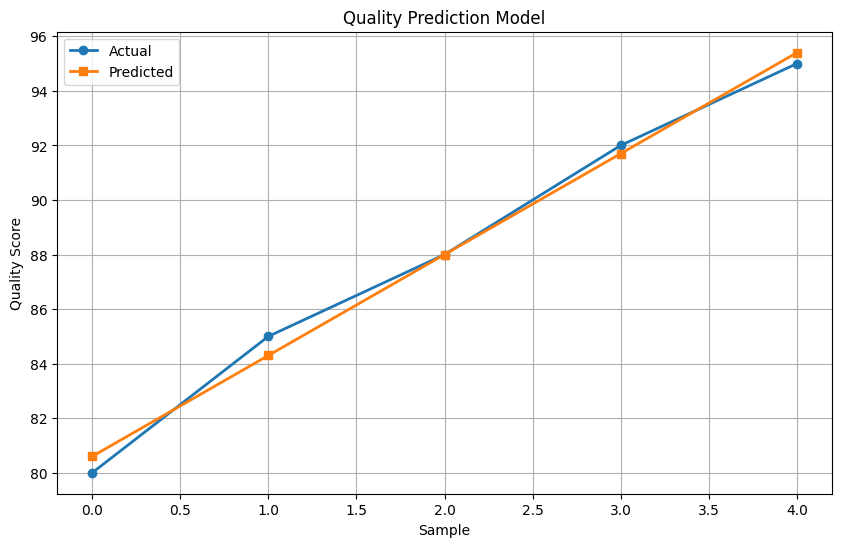

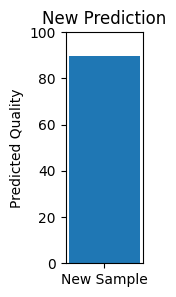

In [20]:
# 시각화

import matplotlib.pyplot as plt

# 학습 데이터 예측
y_pred = model.predict(X)

plt.figure(figsize=(10,6))

# 실제값
plt.plot(
    y.values,
    marker='o',
    linewidth=2,
    label='Actual'
)

# 예측값
plt.plot(
    y_pred,
    marker='s',
    linewidth=2,
    label='Predicted'
)

plt.title("Quality Prediction Model")
plt.xlabel("Sample")
plt.ylabel("Quality Score")

plt.legend()
plt.grid(True)

plt.show()

# 신규 예측 결과
plt.figure(figsize=(1,3))

plt.bar(
    ["New Sample"],
    [pred]
)

plt.title("New Prediction")
plt.ylabel("Predicted Quality")

plt.ylim(0,100)

plt.show()

In [21]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# 학습 데이터 예측
y_pred = model.predict(X)

mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print("="*50)
print("모델 성능")
print("="*50)
print(f"MAE  : {mae:.4f}")   # 평균 절대 오차
print(f"MSE  : {mse:.4f}")   # Mean Squared Error 평균 제곱오차
print(f"RMSE : {rmse:.4f}")  # Root Mean Squared Error 평균 제곱근 오차
print(f"R²   : {r2:.4f}")    # 결정계수 (설명력, 1과 가까울수록 좋음)

모델 성능
MAE  : 0.4000
MSE  : 0.2200
RMSE : 0.4690
R²   : 0.9920


Text(0, 0.5, 'Residual')

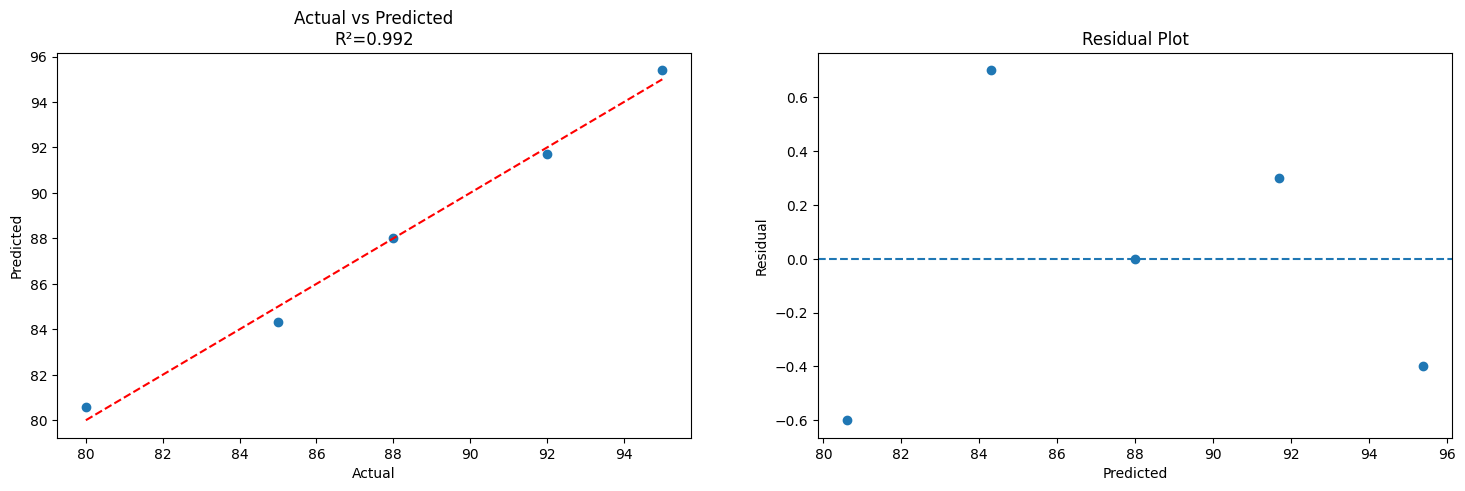

In [33]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18,5)
)

# ------------------
# Actual vs Predicted
# ------------------

axes[0].scatter(y, y_pred)

axes[0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--'
)

axes[0].set_title(
    f'Actual vs Predicted\nR²={r2:.3f}'
)

axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

# ------------------
# Residual
# ------------------

residuals = y - y_pred

axes[1].scatter(
    y_pred,
    residuals
)

axes[1].axhline(
    y=0,
    linestyle='--'
)

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')
# axes[1].set_ylim(-2, 2)

# # ------------------
# # Error Histogram
# # ------------------

# axes[2].hist(
#     residuals,
#     bins=10
# )

# axes[2].set_title('Error Distribution')
# axes[2].set_xlabel('Error')
# axes[2].set_ylabel('Count')

# plt.tight_layout()

# plt.show()